#### Author's Information:
        Author : Ali Rizvi.
        Stu ID : 2410057
        Module : HEP502 of MSc Computer Sciences with Artificial Intelligence.
        Title  : Comparative Evaluation of MLP and CNN on Fashion-MNIST.
        Purpose: Final Assessment
---

| #| ## of Notebook | Title of Notebook |
|--|---|---|
| 1st | 00 | Data Loading and Sanity Checks |
| **2**| **01** | **Baseline MLP** |
| 3| 02 | Baseline CNN |
| 4| 03 | Regularisation Experiments |
| 5| 04 | Depth and Capacity Variance |
| 6| 05 | Robustness Testing |
| 7| 06 | Consolidated Analysis |

**This is Notebook 01,** 2nd of this 7-notebook series. The following are the goals of this notebook:
## Goals:
1) Load prepared data (train/val/test)
2) Build a simple MLP baseline
3) Train with fixed settings (no tuning yet)
4) Evaluate and plot learning curves
5) Save artefacts, such as model, metrics, and figures of MLP baseline.

**This notebook contains implementation of baseline MLP**

#### Importing libraries

In [3]:
import json
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

#### Setting up reproductibility and output folders

In [5]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [9]:
OUTPUT_DIR = Path("outputs")
FIG_DIR = OUTPUT_DIR / "figures"
LOG_DIR = OUTPUT_DIR / "logs"
MODEL_DIR = OUTPUT_DIR / "models"

directories = [OUTPUT_DIR, FIG_DIR, LOG_DIR, MODEL_DIR]

In [10]:
for directory in directories:
    directory.mkdir(parents=True, exist_ok=True)
    
print(f"Outputs will be saved to: {OUTPUT_DIR.resolve()}")

Outputs will be saved to: C:\Users\ALI\PG\HEP502_work\alirizvi_2410057_hep502\code_mlp_vs_cnn\outputs


### Load prepared data

In [11]:
data_path = OUTPUT_DIR / "fashion_mnist_prepared_00.npz"

# Make sure that we have our splits ready
assert data_path.exists(), f"Missing file: {data_path}. Run notebook 00 first"

In [12]:
# Load the splitted dataset
data = np.load(data_path)
x_train = data["x_train"]
y_train = data["y_train"]
x_val = data["x_val"]
y_val = data["y_val"]
x_test = data["x_test"]
y_test = data["y_test"]

In [13]:
# Verfiy the shape and dtypes
print(f"x_train shape: {x_train.shape} | x_train type: {x_train.dtype}")
print(f"x_val shape: {x_val.shape} | x_val type: {x_val.dtype}")
print(f"x_test shape: {x_test.shape} | x_test type: {x_test.dtype}")
print(f"y_train shape: {y_train.shape} | y_train type: {y_train.dtype}")

x_train shape: (48000, 28, 28) | x_train type: float32
x_val shape: (12000, 28, 28) | x_val type: float32
x_test shape: (10000, 28, 28) | x_test type: float32
y_train shape: (48000,) | y_train type: uint8


### Preprocess inputs for **MLP**
Since an MLP expects vectors, not images (2D), flattening of images is required.

In [14]:
def flatten_images(x):
    # convert (N, 28, 28) to (N, 784) for MLP input
    return x.reshape((x.shape[0], -1))

In [15]:
# Flattening all the splits
x_train_mlp = flatten_images(x_train)
x_val_mlp = flatten_images(x_val)
x_test_mlp = flatten_images(x_test)

# Check
print(f"MLP input shape: {x_train_mlp.shape}")

MLP input shape: (48000, 784)


### Setting up a **Multiple Layer Perceptron (MLP)**
#### Defining a baseline MLP model
I'll use 128 units as the baseline

In [16]:
def build_baseline_mlp(input_shape=(784,), num_classes=10):
    # input layer expects flattened images as done above
    inputs = keras.Input(shape=input_shape, name="images")
    
    # single hidden layer as a simple baseline
    x = layers.Dense(128, activation="relu", name="dense_128")(inputs)
    
    # softmax for multi-class classification
    outputs = layers.Dense(num_classes, activation="softmax", name="preds")(x)

    model = keras.Model(inputs, outputs, name="baseline_mlp")
    return model

In [17]:
# Build the model
model = build_baseline_mlp()
model.summary()

Model: "baseline_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ images (InputLayer)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_128 (Dense)                    │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ preds (Dense)                        │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

#### Compiling the model
Using `sparse_categorical_crossentropy` as the loss function because the labels are integers

In [19]:
# standard setup for multiclass classification with integer labels
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),  # stable default choice
    loss="sparse_categorical_crossentropy",  # labels are not one-hot encoded
    metrics=["accuracy"]
)

#### Trainging the model

In [20]:
EPOCHS = 20
BATCH_SIZE = 128

# track total training time for later comparison 
start_time = time.time()

history = model.fit(
    x_train_mlp, y_train,
    validation_data=(x_val_mlp, y_val), # monitor generalisation during training
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)

train_time_sec = time.time() - start_time
print(f"Training time: {train_time_sec:.2f} seconds")

Epoch 1/20
375/375 - 5s - 12ms/step - accuracy: 0.8011 - loss: 0.5814 - val_accuracy: 0.8402 - val_loss: 0.4527
Epoch 2/20
375/375 - 5s - 13ms/step - accuracy: 0.8523 - loss: 0.4233 - val_accuracy: 0.8533 - val_loss: 0.4125
Epoch 3/20
375/375 - 5s - 14ms/step - accuracy: 0.8660 - loss: 0.3813 - val_accuracy: 0.8562 - val_loss: 0.3947
Epoch 4/20
375/375 - 5s - 14ms/step - accuracy: 0.8745 - loss: 0.3538 - val_accuracy: 0.8622 - val_loss: 0.3795
Epoch 5/20
375/375 - 5s - 14ms/step - accuracy: 0.8801 - loss: 0.3339 - val_accuracy: 0.8661 - val_loss: 0.3663
Epoch 6/20
375/375 - 5s - 14ms/step - accuracy: 0.8854 - loss: 0.3179 - val_accuracy: 0.8667 - val_loss: 0.3612
Epoch 7/20
375/375 - 3s - 8ms/step - accuracy: 0.8905 - loss: 0.3041 - val_accuracy: 0.8699 - val_loss: 0.3564
Epoch 8/20
375/375 - 5s - 13ms/step - accuracy: 0.8938 - loss: 0.2920 - val_accuracy: 0.8723 - val_loss: 0.3513
Epoch 9/20
375/375 - 5s - 14ms/step - accuracy: 0.8984 - loss: 0.2815 - val_accuracy: 0.8742 - val_loss: 

#### Plotting the learning curves

In [21]:
def plot_history(history, title_prefix=""):
    hist = history.history # Contains metric values recorded at each epoch
    
    # Loss
    plt.figure(figsize=(6, 4))
    plt.plot(hist["loss"], label="train")
    plt.plot(hist["val_loss"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Accuracy
    plt.figure(figsize=(6, 4))
    plt.plot(hist["accuracy"], label="train")
    plt.plot(hist["val_accuracy"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

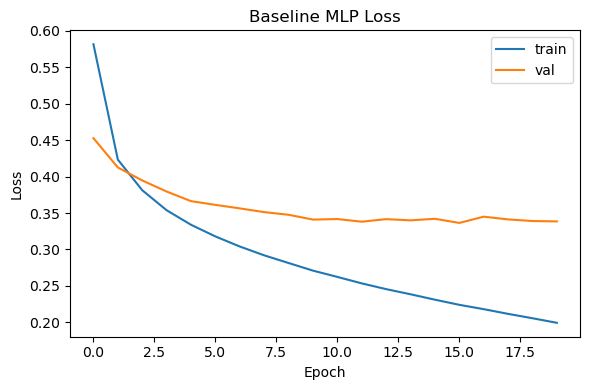

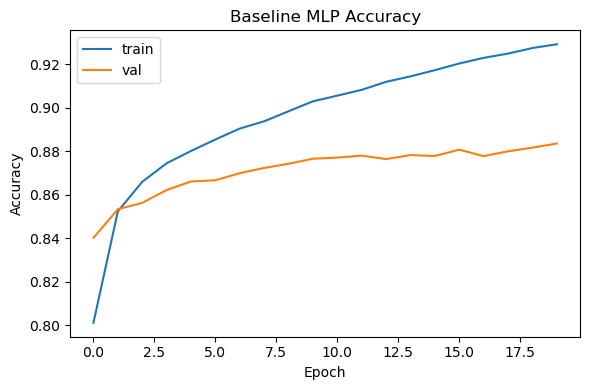

In [22]:
plot_history(history, title_prefix="Baseline MLP")

### Evaluate on the **test set**

In [23]:
test_loss, test_acc = model.evaluate(x_test_mlp, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

Test accuracy: 0.8750
Test loss: 0.3785


### Gathering model's summaries, metrics and artefacts

In [24]:
num_params = model.count_params()
print(f"Total parameters: {num_params}")

Total parameters: 101770


In [25]:
acc_per_10k_params = test_acc / (num_params / 10_000)
print(f"Accuracy per 10k params: {acc_per_10k_params:.4f}")

Accuracy per 10k params: 0.0860


In [26]:
def save_history_plots(history, out_prefix):
     # dictionary containing metrics logged during training
    hist = history.history
    
    # Loss
    plt.figure(figsize=(6, 4))
    plt.plot(hist["loss"], label="train")
    plt.plot(hist["val_loss"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{out_prefix}_loss.png", dpi=150)
    plt.close()
    
    # Accuracy
    plt.figure(figsize=(6, 4))
    plt.plot(hist["accuracy"], label="train")
    plt.plot(hist["val_accuracy"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{out_prefix}_accuracy.png", dpi=150)
    plt.close()

# Store training curves for reporting
save_history_plots(history, "baseline_mlp")
print(f"Saved plots to: {FIG_DIR}")

Saved plots to: outputs\figures


In [27]:
# Save the model
model_path = MODEL_DIR / "baseline_mlp.keras"
model.save(model_path)
print(f"Saved model to: {model_path}")

# Save metrics and settings
run_info = {
    "model_name": model.name,
    "seed": SEED,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "optimizer": "Adam",
    "learning_rate": 1e-3,
    "train_time_sec": train_time_sec,
    "num_params": int(num_params),
    "test_loss": float(test_loss),
    "test_accuracy": float(test_acc),
    "acc_per_10k_params": float(acc_per_10k_params),
    "final_train_accuracy": float(history.history["accuracy"][-1]),
    "final_val_accuracy": float(history.history["val_accuracy"][-1]),
}

Saved model to: outputs\models\baseline_mlp.keras


In [28]:
# Persist run metadata
log_path = LOG_DIR / "baseline_mlp_metrics.json"
with open(log_path, "w") as f:
    json.dump(run_info, f, indent=2)

print(f"Saved metrics to: {log_path}")

Saved metrics to: outputs\logs\baseline_mlp_metrics.json
